# 02 — House-price modeling with a log-price target

This is the project's single modeling notebook. All candidate models are fitted to `log1p(SalePrice)`, selected using validation metrics on the log-price scale, and evaluated once on the held-out test set after selection.

## Modeling protocol

- Fixed shuffled split: 1,800 training, 600 validation, and 508 test observations.
- The 47-feature contract is identical to the EDA notebook.
- Numeric predictors and the ordinal basement-quality variable are standardized within each fit. Neighborhood indicators remain 0/1.
- `log1p(SalePrice)` is standardized internally during fitting, then returned to the log-price scale before all reported metrics are calculated. Thus MSE, RMSE, and MAE are not arbitrary standardized-unit scores.
- Candidate models are selected exclusively by validation MSE. Test metrics are calculated only for the selected model, never used for selection.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')

DATA_FILENAME = 'IA_House_Price_Original_Data.xlsx'
DATA_CANDIDATES = [Path('../data') / DATA_FILENAME, Path('data') / DATA_FILENAME]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f'Could not find {DATA_FILENAME} in the repository data directory.')
TARGET = 'SalePrice'
RANDOM_SEED = 20260928

numeric_features = [
    'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'FullBath',
    'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
]
neighbourhoods = [
    'Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor', 'Edwards',
    'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NPkVill', 'NWAmes', 'NoRidge',
    'NridgHt', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber', 'Veenker',
]
bsmtqual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}


In [16]:
raw = pd.read_excel(DATA_PATH, skiprows=3)
raw.columns = raw.columns.astype(str).str.strip()
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')].copy()

clean = raw.copy()
clean['BsmtFinSF'] = clean['BsmtFinSF1'] + clean['BsmtFinSF2']
clean['BsmtQual_ordinal'] = clean['BsmtQual'].fillna('NA').map(bsmtqual_map)

if set(clean['Neighborhood'].dropna()) != set(neighbourhoods):
    raise ValueError('Neighborhood categories do not match the 25-feature specification.')
neighbourhood_columns = [f'NBHD_{name}' for name in neighbourhoods]
dummies = pd.get_dummies(clean['Neighborhood'], prefix='NBHD', dtype=int).reindex(
    columns=neighbourhood_columns, fill_value=0
)
X_47 = pd.concat([clean[numeric_features], clean[['BsmtQual_ordinal']], dummies], axis=1)
y_price = clean[TARGET].copy()

assert X_47.shape[1] == 47, f'Expected 47 features, found {X_47.shape[1]}.'
assert not X_47.isna().any().any(), 'Selected regressors contain missing values.'
assert not y_price.isna().any(), 'SalePrice contains missing values.'

display(pd.Series({
    'observations': len(X_47), 'features': X_47.shape[1],
    'missing_regressor_values': int(X_47.isna().sum().sum()),
    'missing_target_values': int(y_price.isna().sum()),
}).to_frame('value'))


,value
observations,2908
features,47
missing_regressor_values,0
missing_target_values,0


In [17]:
rng = np.random.default_rng(RANDOM_SEED)
permutation = rng.permutation(len(X_47))
train_idx, validation_idx, test_idx = permutation[:1800], permutation[1800:2400], permutation[2400:]

X_train, y_train = X_47.iloc[train_idx], y_price.iloc[train_idx]
X_validation, y_validation = X_47.iloc[validation_idx], y_price.iloc[validation_idx]
X_test, y_test = X_47.iloc[test_idx], y_price.iloc[test_idx]
assert (len(X_train), len(X_validation), len(X_test)) == (1800, 600, 508)

display(pd.DataFrame({
    'observations': [len(X_train), len(X_validation), len(X_test)],
    'mean_saleprice': [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=['train', 'validation', 'test']).round(2))


,observations,mean_saleprice
train,1800,180018.88
validation,600,178133.52
test,508,183695.88


## Models and metrics

OLS, Ridge, and Lasso are fitted with the assignment's specified penalty strengths. The primary metrics below evaluate `log1p(SalePrice)`: MSE, RMSE, MAE, and R². The raw-dollar target is never used as the fitting baseline.

In [18]:
scaled_features = numeric_features + ['BsmtQual_ordinal']

def make_regressor_pipeline(estimator):
    preprocessing = ColumnTransformer(
        [('scaled', StandardScaler(), scaled_features),
         ('neighborhood', 'passthrough', neighbourhood_columns)],
        verbose_feature_names_out=False,
    )
    return Pipeline([('preprocess', preprocessing), ('model', estimator)])

def make_log_target_model(estimator):
    # Pipeline inversion is StandardScaler inverse followed by expm1.
    target_transformer = Pipeline([
        ('log', FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=False)),
        ('scale', StandardScaler()),
    ])
    return TransformedTargetRegressor(
        regressor=make_regressor_pipeline(estimator),
        transformer=target_transformer,
    )

def log_scale_metrics(actual_price, predicted_price):
    actual_log = np.log1p(actual_price)
    predicted_log = np.log1p(np.maximum(predicted_price, 0))
    return {
        'mse': mean_squared_error(actual_log, predicted_log),
        'rmse': np.sqrt(mean_squared_error(actual_log, predicted_log)),
        'mae': mean_absolute_error(actual_log, predicted_log),
        'r2': r2_score(actual_log, predicted_log),
    }

candidates = {
    'OLS': LinearRegression(),
    **{f'Ridge (alpha={alpha:.2f})': Ridge(alpha=alpha) for alpha in [0.10, 0.30, 0.60]},
    **{f'Lasso (alpha={alpha:.2f})': Lasso(alpha=alpha, max_iter=50_000) for alpha in [0.02, 0.06, 0.10]},
}

fitted_candidates, records = {}, []
for name, estimator in candidates.items():
    model = make_log_target_model(estimator)
    model.fit(X_train, y_train)
    fitted_candidates[name] = model
    train_metrics = log_scale_metrics(y_train, model.predict(X_train))
    validation_metrics = log_scale_metrics(y_validation, model.predict(X_validation))
    records.append({
        'model': name,
        **{f'train_{metric}': value for metric, value in train_metrics.items()},
        **{f'validation_{metric}': value for metric, value in validation_metrics.items()},
    })

model_metrics = pd.DataFrame(records).sort_values('validation_mse').reset_index(drop=True)
best_validation_mse = model_metrics.loc[0, 'validation_mse']
model_metrics['validation_mse_delta_to_best'] = model_metrics['validation_mse'] - best_validation_mse
model_metrics['validation_mse_pct_above_best'] = 100 * model_metrics['validation_mse_delta_to_best'] / best_validation_mse
display(model_metrics.round(8))


,model,train_mse,train_rmse,train_mae,train_r2,validation_mse,validation_rmse,validation_mae,validation_r2,validation_mse_delta_to_best,validation_mse_pct_above_best
0,Ridge (alpha=0.60),0.013904,0.117914,0.081020,0.912083,0.014929,0.122186,0.083999,0.914837,0.000000,0.000000
1,Ridge (alpha=0.30),0.013902,0.117908,0.081008,0.912092,0.014933,0.122201,0.084024,0.914816,0.000004,0.024688
2,Ridge (alpha=0.10),0.013902,0.117906,0.081004,0.912094,0.014936,0.122213,0.084046,0.914798,0.000007,0.045299
3,OLS,0.013902,0.117906,0.081003,0.912095,0.014938,0.122220,0.084057,0.914788,0.000009,0.056989
4,Lasso (alpha=0.02),0.016669,0.129110,0.091020,0.894595,0.017505,0.132305,0.092142,0.900147,0.002575,17.249235
5,Lasso (alpha=0.06),0.019338,0.139063,0.097379,0.877718,0.021760,0.147513,0.103026,0.875871,0.006831,45.754038
6,Lasso (alpha=0.10),0.022969,0.151554,0.107108,0.854762,0.026563,0.162982,0.114689,0.848473,0.011634,77.925599


## Final test evaluation

Only the candidate with the lowest validation MSE is refitted on training plus validation data. This prevents test-set metrics from influencing model selection.

,selected_model,target_for_metrics,test_mse,test_rmse,test_mae,test_r2
0,Ridge (alpha=0.60),log1p(SalePrice),0.0145,0.1204,0.0865,0.9083


,test_rmse_usd,test_mae_usd
0,21558.74,15045.23


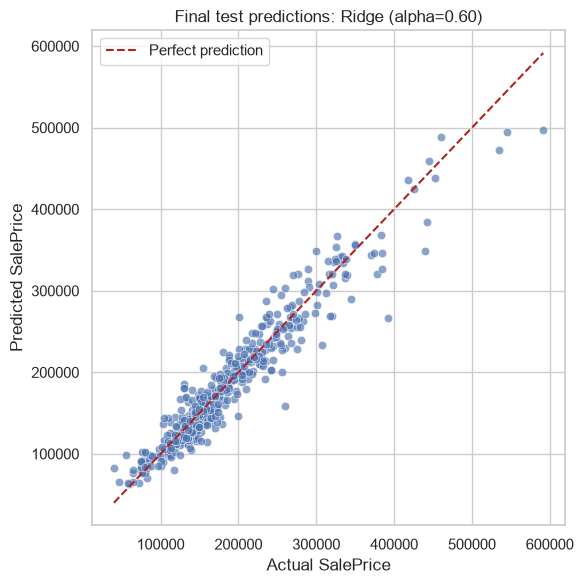

In [20]:
best_model_name = model_metrics.loc[0, 'model']
best_estimator = candidates[best_model_name]
X_development = pd.concat([X_train, X_validation])
y_development = pd.concat([y_train, y_validation])

final_model = make_log_target_model(best_estimator)
final_model.fit(X_development, y_development)
test_prediction = final_model.predict(X_test)
test_metrics = log_scale_metrics(y_test, test_prediction)

final_test_metrics = pd.DataFrame([{
    'selected_model': best_model_name,
    'target_for_metrics': 'log1p(SalePrice)',
    'test_mse': test_metrics['mse'],
    'test_rmse': test_metrics['rmse'],
    'test_mae': test_metrics['mae'],
    'test_r2': test_metrics['r2'],
}])
display(final_test_metrics.round(4))

dollar_metrics = pd.DataFrame([{
    'test_rmse_usd': np.sqrt(mean_squared_error(y_test, test_prediction)),
    'test_mae_usd': mean_absolute_error(y_test, test_prediction),
}])
display(dollar_metrics.round(2))

plot_data = pd.DataFrame({'actual_saleprice': y_test, 'predicted_saleprice': test_prediction})
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(data=plot_data, x='actual_saleprice', y='predicted_saleprice', alpha=0.65)
limits = [plot_data.min().min(), plot_data.max().max()]
ax.plot(limits, limits, '--', color='firebrick', label='Perfect prediction')
ax.set(title=f'Final test predictions: {best_model_name}', xlabel='Actual SalePrice', ylabel='Predicted SalePrice')
ax.legend()
plt.tight_layout()
plt.show()


Best model selected by validation MSE: Ridge (alpha=0.60)
Coefficients are in log-price units. Numerical feature coefficients correspond to standardized predictors.


,feature,log_price_coefficient,abs_coefficient
32,NBHD_MeadowV,-0.164706,0.164706
24,NBHD_BrDale,-0.144511,0.144511
28,NBHD_Crawfor,0.141404,0.141404
23,NBHD_Blueste,-0.126587,0.126587
44,NBHD_StoneBr,0.115911,0.115911
10,GrLivArea,0.109356,0.109356
1,OverallQual,0.096716,0.096716
38,NBHD_NridgHt,0.094713,0.094713
3,YearBuilt,0.089776,0.089776
35,NBHD_NPkVill,-0.076475,0.076475


,display_feature,log_price_coefficient
7,Crawfor,0.141404
23,StoneBr,0.115911
17,NridgHt,0.094713
22,Somerst,0.062134
16,NoRidge,0.058951
5,ClearCr,0.048809
24,Timber,0.042952
6,CollgCr,0.031453
4,BrkSide,0.027807
9,Gilbert,0.022275


,feature,log_price_coefficient
10,GrLivArea,0.109356
1,OverallQual,0.096716
3,YearBuilt,0.089776
2,OverallCond,0.063315
7,TotalBsmtSF,0.038178
5,BsmtFinSF,0.037106
16,GarageCars,0.022525
17,GarageArea,0.021573
15,Fireplaces,0.020422
0,LotArea,0.019178


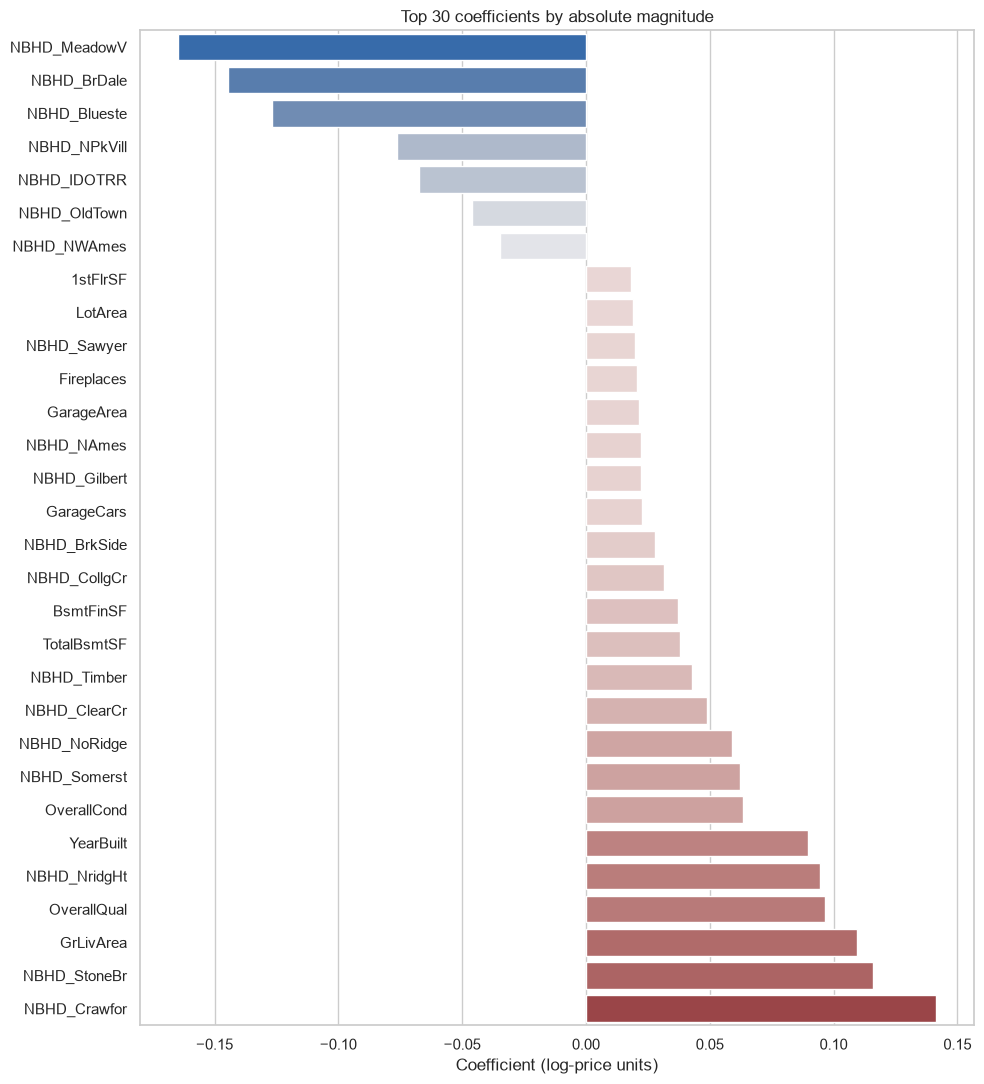

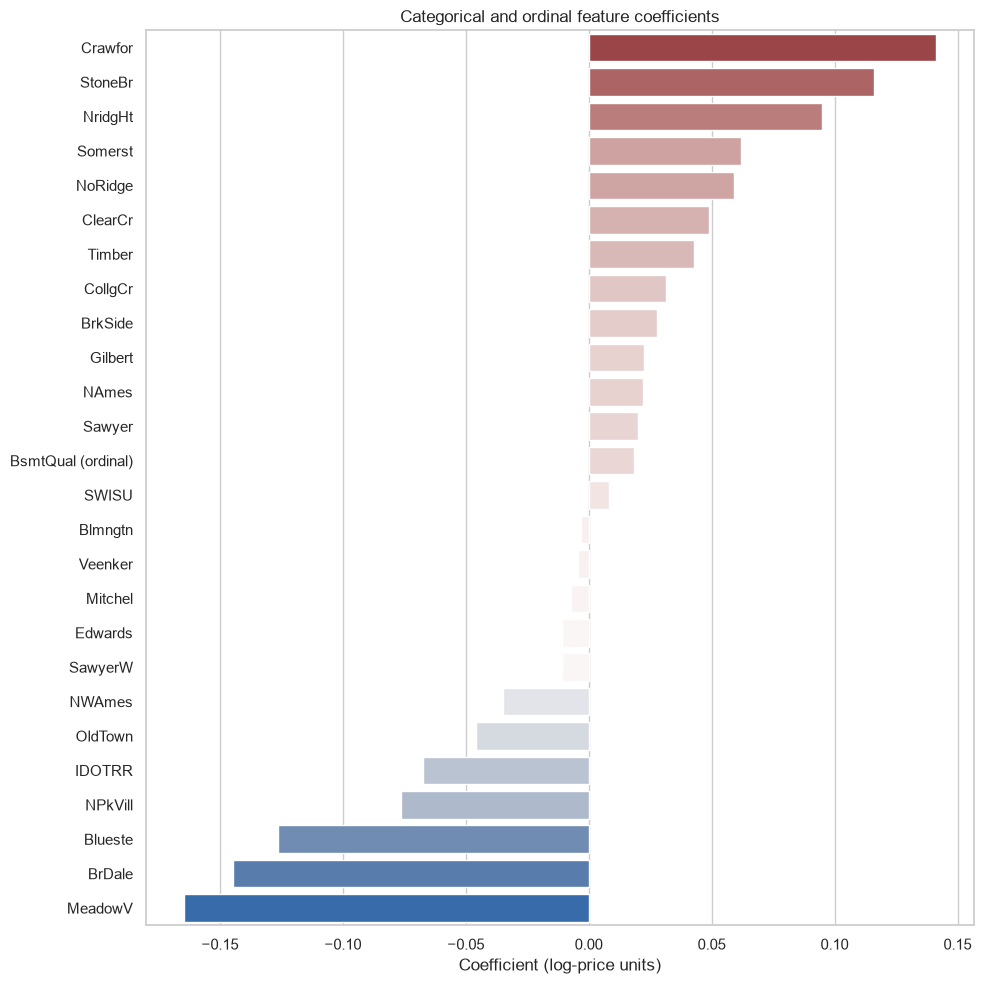

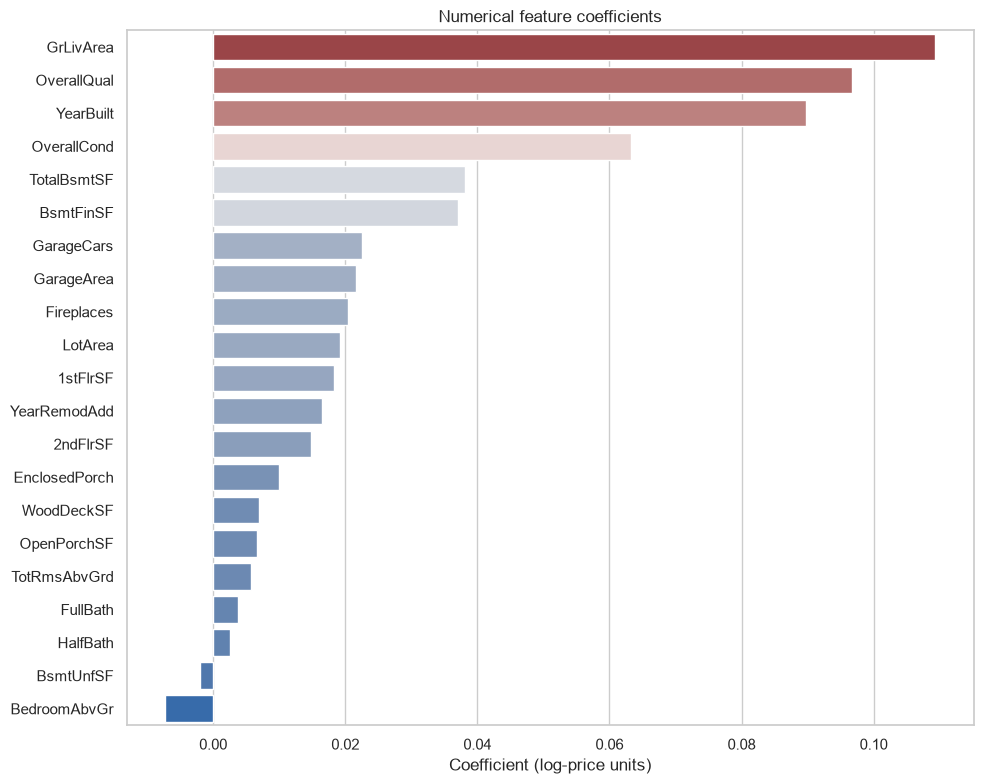

In [21]:
# Convert coefficients from standardized-target units back to log-price units.
target_log_std = final_model.transformer_.named_steps['scale'].scale_[0]
coefficient_table = pd.DataFrame({
    'feature': final_model.regressor_.named_steps['preprocess'].get_feature_names_out(),
    'log_price_coefficient': final_model.regressor_.named_steps['model'].coef_ * target_log_std,
})
coefficient_table['abs_coefficient'] = coefficient_table['log_price_coefficient'].abs()

# 1. Top 30 coefficients by absolute magnitude across all 47 features.
top_30_coefficients = coefficient_table.sort_values('abs_coefficient', ascending=False).head(30)

# 2. Categorical features: one ordinal basement-quality feature plus 25 neighborhood indicators.
categorical_features = ['BsmtQual_ordinal'] + neighbourhood_columns
categorical_coefficients = coefficient_table.set_index('feature').loc[categorical_features].reset_index()
categorical_coefficients['display_feature'] = categorical_coefficients['feature'].replace({'BsmtQual_ordinal': 'BsmtQual (ordinal)'})
categorical_coefficients['display_feature'] = categorical_coefficients['display_feature'].str.removeprefix('NBHD_')
categorical_coefficients = categorical_coefficients.sort_values('log_price_coefficient', ascending=False)

# 3. Numerical features: all 21 numeric features in the assignment contract.
numerical_coefficients = coefficient_table.set_index('feature').loc[numeric_features].reset_index()
numerical_coefficients = numerical_coefficients.sort_values('log_price_coefficient', ascending=False)

print(f'Best model selected by validation MSE: {best_model_name}')
print('Coefficients are in log-price units. Numerical feature coefficients correspond to standardized predictors.')
display(top_30_coefficients[['feature', 'log_price_coefficient', 'abs_coefficient']].round(8))
display(categorical_coefficients[['display_feature', 'log_price_coefficient']].round(8))
display(numerical_coefficients[['feature', 'log_price_coefficient']].round(8))

fig, axis = plt.subplots(figsize=(10, 11))
sns.barplot(data=top_30_coefficients.sort_values('log_price_coefficient'),
            x='log_price_coefficient', y='feature', hue='log_price_coefficient',
            palette='vlag', legend=False, ax=axis)
axis.set(title='Top 30 coefficients by absolute magnitude', xlabel='Coefficient (log-price units)', ylabel='')
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(10, 10))
sns.barplot(data=categorical_coefficients, x='log_price_coefficient', y='display_feature',
            hue='log_price_coefficient', palette='vlag', legend=False, ax=axis)
axis.set(title='Categorical and ordinal feature coefficients', xlabel='Coefficient (log-price units)', ylabel='')
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(10, 8))
sns.barplot(data=numerical_coefficients, x='log_price_coefficient', y='feature',
            hue='log_price_coefficient', palette='vlag', legend=False, ax=axis)
axis.set(title='Numerical feature coefficients', xlabel='Coefficient (log-price units)', ylabel='')
plt.tight_layout()
plt.show()


## Interpretation guardrails

The reported primary metrics are on the log-price scale, so they measure proportional pricing error more naturally than dollar-scale errors. Dollar RMSE and MAE are supplied only as an intuitive supplement for the final selected model. Coefficients are conditional prediction associations, not causal effects. Retaining all 25 neighborhood dummies honors the 47-feature contract; with an intercept, OLS dummy coefficients are not individually identified even though its predictions are well-defined.

## Model Prediction

This section applies the existing final model to 4015 Marigold Dr, Ames, IA 50014, an external single-family property in the Edwards neighborhood. The row is not added to the training, validation, or test partitions and does not affect model selection. The audit table reports every input and its source; values labelled Estimated from Zillow listing are baseline assumptions rather than verified property facts.

In [7]:
external_property_values = {
    'LotArea': 7405.2, 'OverallQual': 7, 'OverallCond': 6, 'YearBuilt': 2002,
    'YearRemodAdd': 2024, 'BsmtFinSF': 1286, 'BsmtUnfSF': 0, 'TotalBsmtSF': 1286,
    '1stFlrSF': 1000, '2ndFlrSF': 351, 'GrLivArea': 1351, 'FullBath': 2,
    'HalfBath': 0, 'BedroomAbvGr': 4, 'TotRmsAbvGrd': 7, 'Fireplaces': 1,
    'GarageCars': 2, 'GarageArea': 424, 'WoodDeckSF': 173, 'OpenPorchSF': 0,
    'EnclosedPorch': 0, 'BsmtQual_ordinal': 4,
}
provided_sources = {
    'LotArea': 'Zillow Listing', 'YearBuilt': 'Zillow Listing',
    'BsmtFinSF': 'Zillow Listing', 'BsmtUnfSF': 'Zillow Listing',
    'TotalBsmtSF': 'Zillow Listing', 'GrLivArea': 'Zillow Listing',
    'FullBath': 'Zillow Listing', 'HalfBath': 'Zillow Listing',
    'BedroomAbvGr': 'Zillow Listing', 'Fireplaces': 'Zillow Listing',
    'GarageCars': 'Zillow Listing',
}
estimated_source = 'Estimated from Zillow listing'
external_property_values.update({f'NBHD_{name}': int(name == 'Edwards') for name in neighbourhoods})
external_property_sources = {feature: provided_sources.get(feature, estimated_source) for feature in X_47.columns}
external_property_sources.update({f'NBHD_{name}': 'Zillow Listing' for name in neighbourhoods})
external_property = pd.DataFrame([external_property_values], columns=X_47.columns)
assert external_property.shape == (1, 47)
assert external_property.columns.equals(X_47.columns)
assert not external_property.isna().any().any()
assert external_property.at[0, 'NBHD_Edwards'] == 1
assert external_property.filter(like='NBHD_').sum(axis=1).eq(1).all()
external_property_audit = pd.DataFrame({'Data': external_property.iloc[0], 'Source': pd.Series(external_property_sources)}).loc[X_47.columns]
external_property_audit.index.name = 'Feature'
print(external_property_audit.to_string())

external_prediction_usd = float(final_model.predict(external_property)[0])
model_prediction = pd.DataFrame([{
    'property': '4015 Marigold Dr, Ames, IA 50014',
    'neighborhood': 'Edwards', 'selected_model': best_model_name,
    'predicted_saleprice_usd': external_prediction_usd,
    'predicted_log1p_saleprice': np.log1p(max(external_prediction_usd, 0)),
}])
print(model_prediction.round({'predicted_saleprice_usd': 2, 'predicted_log1p_saleprice': 8}).to_string(index=False))


                    Data                         Source
Feature                                                
LotArea           7405.2                 Zillow Listing
OverallQual          7.0  Estimated from Zillow listing
OverallCond          6.0  Estimated from Zillow listing
YearBuilt         2002.0                 Zillow Listing
YearRemodAdd      2024.0  Estimated from Zillow listing
BsmtFinSF         1286.0                 Zillow Listing
BsmtUnfSF            0.0                 Zillow Listing
TotalBsmtSF       1286.0                 Zillow Listing
1stFlrSF          1000.0  Estimated from Zillow listing
2ndFlrSF           351.0  Estimated from Zillow listing
GrLivArea         1351.0                 Zillow Listing
FullBath             2.0                 Zillow Listing
HalfBath             0.0                 Zillow Listing
BedroomAbvGr         4.0                 Zillow Listing
TotRmsAbvGrd         7.0  Estimated from Zillow listing
Fireplaces           1.0                 Zillow 